In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from __future__ import print_function, division
import time
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import TensorFlow Keras instead of standalone Keras
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, concatenate, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K  # Use TF's backend

warnings.filterwarnings("ignore")

In [ ]:
class AE_WGAN():
    def __init__(self):
        self.img_rows = 4
        self.img_cols = 6
        self.channels = 1
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = 32

        self.critic_updates = 5
        self.sum_time_generating = 0

        optimizer = optimizers.Adamax(.00009)

        # Build and compile the critic
        self.critic = self.build_critic()
        self.critic.compile(loss=[self.wasserstein_loss],
                                   optimizer=optimizer,
                                   metrics=['accuracy'])

        # Build the generator
        self.generator = self.build_generator()

        # Build the encoder
        self.encoder = self.build_encoder()

        # The part of the AE_WGAN that trains the critic and encoder
        self.critic.trainable = False

        # Generate image from sampled noise
        z = Input(shape=(self.latent_dim, ))
        img_ = self.generator(z)

        # Encode image
        img = Input(shape=self.img_shape)
        z_ = self.encoder(img)

        # Latent -> img is fake, and img -> latent is valid
        fake = self.critic([z, img_])  # generator
        valid = self.critic([z_, img]) # encoder

        # Set up and compile the combined model
        # Trains generator to fool the critic
        self.AE_WGAN_generator = Model([z, img], [fake, valid])
        self.AE_WGAN_generator.compile(loss=[self.wasserstein_loss, self.wasserstein_loss],
                                       optimizer=optimizer)

    def wasserstein_loss(self, y_true, y_pred):
        return K.mean(y_true * y_pred)

    def gradient_penalty_loss(self, real_imgs, fake_imgs):
        batch_size = real_imgs.shape[0]
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
        interpolated = tf.Variable(interpolated)

        z_dummy = tf.zeros((batch_size, self.latent_dim), dtype=tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = self.critic([z_dummy, interpolated])

        gradients = tape.gradient(pred, interpolated)
        gradients_sqr = tf.square(gradients)
        gradients_sqr_sum = tf.reduce_sum(gradients_sqr, axis=np.arange(1, len(gradients.shape)))
        gradient_l2_norm = tf.sqrt(gradients_sqr_sum + 1e-12)
        gradient_penalty = tf.square(gradient_l2_norm - 1)
        return tf.reduce_mean(gradient_penalty)

    def build_encoder(self):
        model = Sequential()

        model.add(Flatten(input_shape=self.img_shape))
        model.add(Dense(20, activation='relu'))
        model.add(Dense(self.latent_dim))

        model.summary()

        img = Input(shape=self.img_shape)

        z = model(img)
        return Model(img, z)

    def build_generator(self):
        model = Sequential()

        model.add(Dense(40, input_dim=self.latent_dim, activation='relu'))
        model.add(Dense(80, activation='relu'))
        model.add(Dense(120, activation='relu'))
        model.add(Dense(np.prod(self.img_shape), activation='relu'))
        model.add(Reshape(self.img_shape))

        model.summary()

        z = Input(shape=(self.latent_dim,))
        gen_img = model(z)
        return Model(z, gen_img)

    def build_critic(self):
        model = Sequential()

        model.add(Dense(80, activation='relu', input_dim=self.latent_dim + np.prod(self.img_shape)))
        model.add(Dense(40, activation='relu'))
        model.add(Dense(1, activation='linear'))

        model.summary()

        img = Input(shape=self.img_shape)
        z = Input(shape=(self.latent_dim,))

        d_in = concatenate([z, Flatten()(img)])

        validity = model(d_in)
        return Model([z, img], validity)

    def train(self, attack_name, epochs, batch_size=32):
        epoch_list = []
        loss_D = []
        acc_D = []
        loss_G = []

        valid = -np.ones((batch_size, 1))
        fake = np.ones((batch_size, 1))

        lambda_gp = 10

        for epoch in range(epochs):
            for _ in range(self.critic_updates):  # Train critic 5 times per generator update
                z = np.random.normal(0, 1, size=(batch_size, self.latent_dim))
                imgs_ = self.generator.predict(z)

                idx = np.random.randint(0, reshaped_X_attack.shape[0], batch_size)
                imgs = reshaped_X_attack[idx]
                z_ = self.encoder.predict(imgs)

                # Train the critic on real and fake
                d_loss_real = self.critic.train_on_batch([z_, imgs], valid)
                d_loss_fake = self.critic.train_on_batch([z, imgs_], fake)

                # Gradient penalty between real and generated
                d_loss_gp = self.gradient_penalty_loss(tf.convert_to_tensor(imgs, dtype=tf.float32),
                                                      tf.convert_to_tensor(imgs_, dtype=tf.float32))

                # Total loss
                d_loss_total = d_loss_real[0] + d_loss_fake[0] + lambda_gp * d_loss_gp
                d_loss = [d_loss_total, d_loss_real[1]]

            # Train the generator (encoder + generator)
            g_loss = self.AE_WGAN_generator.train_on_batch([z, imgs], [valid, fake])
            print("%d [D loss: %f, acc: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[1], g_loss[0]))

            if epoch % 10 == 0:
                loss_D.append(d_loss[0])
                acc_D.append(100*d_loss[1])
                loss_G.append(g_loss[0])
                epoch_list.append(epoch)

            if epoch == 100:
                print('\nGenerating the attack data(', attack_name, ')...\n')
                generated_pics = self.generate_data()

        plt.figure(figsize=(10,7))
        plt.subplot(2, 1, 1)
        plt.title(attack_name)
        plt.plot(epoch_list, loss_D, '-o', label='Critic loss')
        plt.plot(epoch_list, loss_G, '-s', label='Generator loss')
        plt.ylabel('loss')
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(epoch_list, acc_D, '-s', label='Critic accuracy')
        plt.ylabel('accuracy')
        plt.xlabel('epochs')
        plt.legend()
        plt.savefig('./drive/MyDrive/Colab Notebooks/AE_WGAN_NSL_KDD/images/gp/AE_WGAN_NSL_KDD_%s.jpeg' % attack_name, bbox_inches='tight')
        plt.show()

        return generated_pics


    def generate_data(self):
        generated_pics = []
        a = int(len(reshaped_X_attack)+2000)
        for x in range(a):
            noise = np.random.normal(size=(32, self.latent_dim))
            gen_imgs = self.generator.predict(noise)
            generated_pics.append(gen_imgs[0])
        return generated_pics


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 80)                  │           4,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 40)                  │           3,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,841 (30.63 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 20)                  │             500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 32)                  │             672 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,172 (4.58 KB)

 Trainable params: 1,172 (4.58 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
0 [D loss: 1.962520, acc: 26.39%] [G loss: 1.832142]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1 [D loss: 1.774986, acc: 29.61%] [G loss: 1.801011]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━

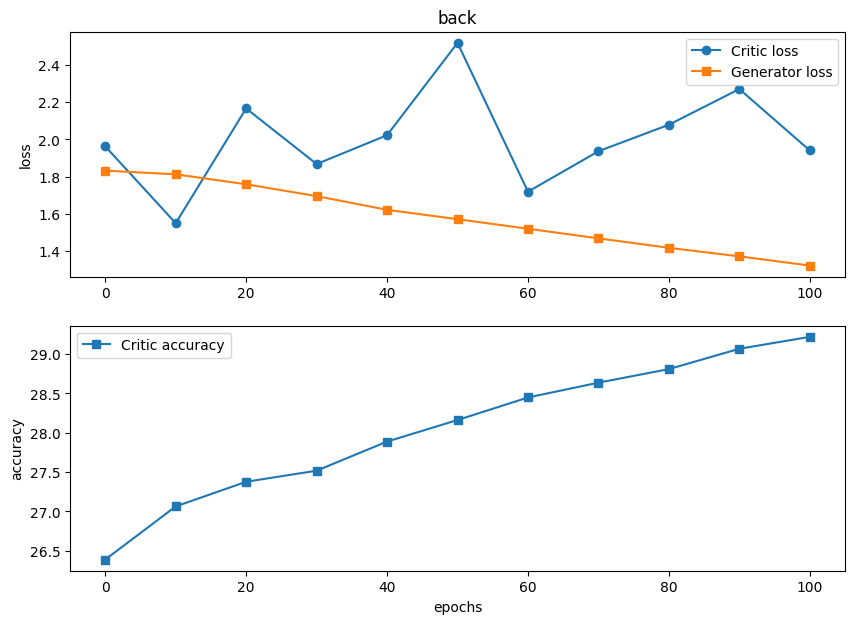

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 80)                  │           4,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 40)                  │           3,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,841 (30.63 KB)

 Non-trainable params: 0 (0.00 B)

...

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-8-600d4e564d63>", line 22, in <cell line: 0>
    generated_pics = ae_wgan.train(attack_name, epochs=101, batch_size=32)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-1cf1fd3ecb6d>", line 159, in train
    generated_pics = self.generate_data()
                     ^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-1cf1fd3ecb6d>", line 184, in generate_data
    gen_imgs = self.generator.predict(noise)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 500, in predict


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-8-600d4e564d63>", line 22, in <cell line: 0>
    generated_pics = ae_wgan.train(attack_name, epochs=101, batch_size=32)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-1cf1fd3ecb6d>", line 159, in train
    generated_pics = self.generate_data()
                     ^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-1cf1fd3ecb6d>", line 184, in generate_data
    gen_imgs = self.generator.predict(noise)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 500, in predict


TypeError: object of type 'NoneType' has no len()

In [ ]:
# Load NSL_KDD Dataset
attack_column='label'

selected_attacks = ["back", "teardrop", "warezclient", "pod", "guess_passwd", "buffer_overflow", "warezmaster", "land", "imap", "rootkit", "loadmodule", "ftp_write", "multihop", "phf", "perl", "spy"]

# Create a directory to save the separated attacks
save_dir = "./drive/MyDrive/Colab Notebooks/AE_WGAN_NSL_KDD/Generated_NSL_KDD/Gradient_penalty/"
os.makedirs(save_dir, exist_ok=True)

for attack_name in selected_attacks:
    attack = pd.read_csv(f'./drive/MyDrive/Colab Notebooks/AE_WGAN_NSL_KDD/Preprocessed_NSL_KDD/{attack_name}.csv')

    X_attack = attack.drop(columns=[attack_column], axis=1)

    X_attack = X_attack.astype(np.float32)
    reshaped_X_attack = np.asarray(X_attack).reshape(-1, 4, 6, 1)

    ae_wgan = AE_WGAN()
    generated_pics = ae_wgan.train(attack_name, epochs=101, batch_size=32)

    generated_attack = np.array(generated_pics).reshape(-1, 24)

    df_generated = pd.DataFrame(generated_attack, columns=X_attack.columns)

    for y in range(attack.shape[0]):
        df_generated['label'] = attack_name

    df_generated.to_csv(f"{save_dir}{attack_name}.csv", index=False)